Loaded checkpoint: <All keys matched successfully>


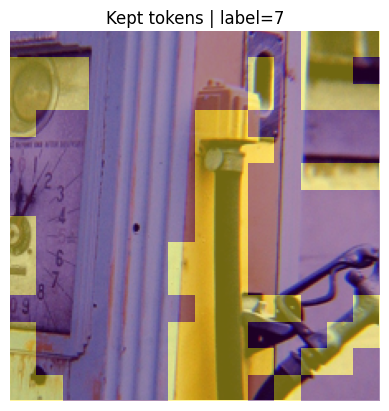

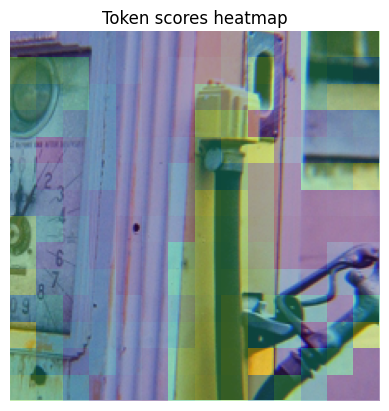

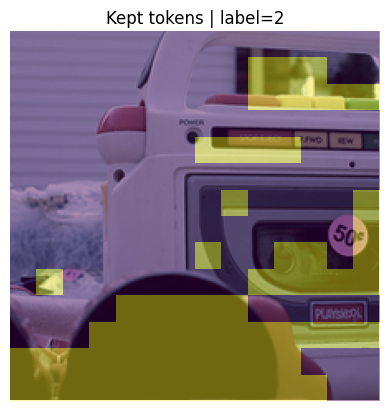

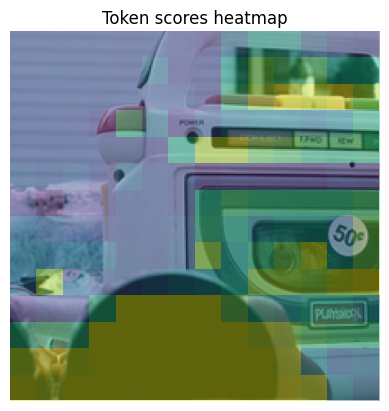

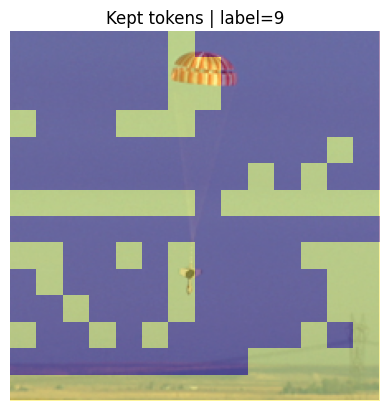

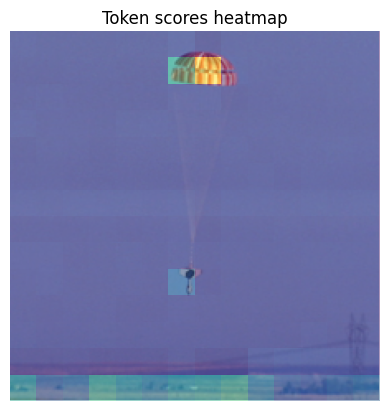

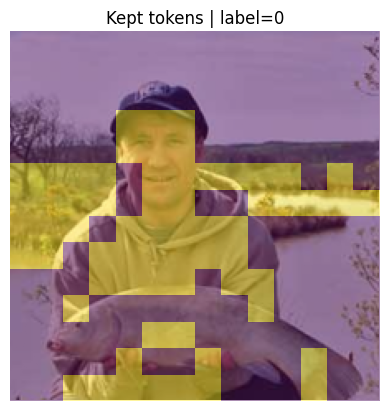

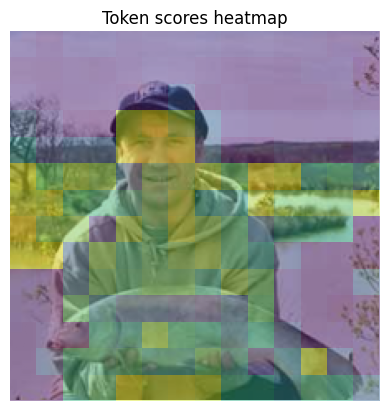

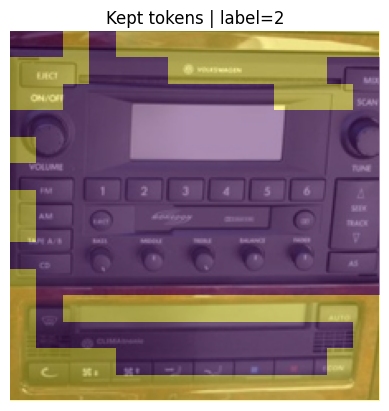

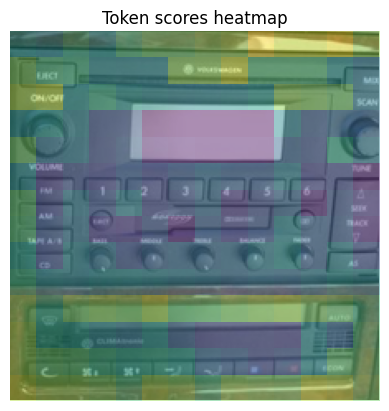

In [3]:
from sympy.core.random import shuffle

from datasets import imagenet_style_loaders
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
# 1) Import your model class (adjust the import path!)
# from refined_vit import RefinedTimmViT
from models.refined_vit import RefinedTimmViT

# 2) Import visualization helpers from your training file
from run_one_epoch import (
    show_token_keep_mask,
    show_token_score_heatmap,
    avg_keep_probability_over_loader,
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 3) Create the model EXACTLY like in training
model = RefinedTimmViT(
    timm_name="vit_base_patch16_224",  # or deit_small_patch16_224
    pretrained=False,                  # IMPORTANT: set this to whatever you used for training
    num_classes=10,                    # Imagenette = 10
    warmup_depth=2,                    # MUST match your training run
    keep_k=64,                         # MUST match your training run
    score_hidden=128,                  # MUST match your training run
).to(device)

# 4) Load checkpoint (adjust path + key names)
ckpt_path = "outputs/best.pth"   # TODO
ckpt = torch.load(ckpt_path, map_location="cpu")

# Common patterns:
# - if you saved torch.save(model.state_dict())
#   then ckpt IS the state_dict
# - if you saved {"model": model.state_dict(), ...}
#   then ckpt["model"] is the state_dict

state_dict = ckpt["model"] if isinstance(ckpt, dict) and "model" in ckpt else ckpt
msg = model.load_state_dict(state_dict, strict=True)
print("Loaded checkpoint:", msg)

model.eval()


# 6) ImageNet normalization (typical for Imagenette)
mean = (0.485, 0.456, 0.406)
std  = (0.229, 0.224, 0.225)

transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

_, test_loader = imagenet_style_loaders(
            data_root="data/imagenette2", batch_size=32
        )

# 5) Pick one image from your test loader (assumes you already built test_loader)
# imgs, labels = next(iter(test_loader))
# img = imgs[0:1].to(device)   # keep batch dim
# label = labels[0].item()

# 7) Run visualizations
#show_token_keep_mask(model, img, mean, std, title=f"Kept tokens | label={label}")
#show_token_score_heatmap(model, img, mean, std, title="Token scores heatmap")

# Optional: dataset-level keep statistics (can take a bit)
# avg_keep_probability_over_loader(model, test_loader, device)

imgs, labels = next(iter(test_loader))
imgs = imgs.to(device)

for i in range(5):   # show 5 examples
    img = imgs[i:i+1]     # keep batch dim
    label = labels[i].item()

    show_token_keep_mask(model, img, mean, std,
                         title=f"Kept tokens | label={label}")
    show_token_score_heatmap(model, img, mean, std, title="Token scores heatmap")$